### 질문 6 가설 검증

In [ ]:
import pandas as pd
import folium
import requests
import re

# 1. 데이터 로드
df_main = pd.read_csv('subway_merged_base.csv') 
borough_df = pd.read_csv('서울교통공사_자치구별지하철역정보_20260212.CSV')
station_df = pd.read_csv('서울시 역사마스터 정보.csv', encoding='cp949') 
priority = pd.read_excel('priority_last.xlsx')
priority_final = pd.read_csv('priority_district.csv')

In [28]:
# 가중 시설 점수 및 시설부하지수 계산
df_main['TOTAL_W'] = df_main['EV'] * 4 + df_main['ES'] * 1
df_main['시설부하지수'] = (df_main['무임승하차'] / df_main['TOTAL_W']).round(2)

# 확인
print(df_main[['지하철역', 'EV', 'ES', 'TOTAL_W', '시설부하지수']].head())

   지하철역  EV  ES  TOTAL_W    시설부하지수
0   제기동   3   2       14  39979.71
1    종각   4   2       18  16260.50
2  종로5가   3   0       12  40693.25
3   청량리   2   6       14  40142.07
4    강남   4   0       16  18886.94


In [ ]:
def clean_name_final(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r'\(.*\)', '', text)
    if text.endswith('역') and len(text) > 2:
        text = text[:-1]
    text = text.replace('환승', '')
    text = re.sub(r'[^가-힣a-zA-Z0-9]', '', text)
    return text.strip()

# 역명_key 생성
df_main['역명_key'] = df_main['지하철역'].apply(clean_name_final)
station_df['역명_key'] = station_df['역사명'].apply(clean_name_final)

# 좌표 merge
station_unique = station_df.drop_duplicates(subset=['역명_key'])
df_all = df_main.merge(
    station_unique[['역명_key', '위도', '경도']],
    on='역명_key',
    how='left'
)

# 자양역 수동 패치 (#으로 loc 부분해보면 좌표없는역 1개 나옴.)
df_all.loc[df_all['역명_key'] == '자양', '위도'] = 37.5397
df_all.loc[df_all['역명_key'] == '자양', '경도'] = 127.0712

print(f"좌표 없는 역: {df_all['위도'].isna().sum()}개")

좌표 없는 역: 1개


In [7]:
print(df_all.columns.tolist())          # 컬럼 목록 확인


['지하철역', '호선명', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차', '무임승하차비중', 'EV', 'ES', 'TOTAL', '시설부하지수', 'TOTAL_W', '역명_key', '위도', '경도']


In [8]:
#print(df_all.columns.duplicated().any()) # 중복 컬럼 있는지 확인
print(borough_df.columns.tolist())

['자치구', '해당역(호선)', '역개수']


In [9]:
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

In [10]:
# 구 정보 merge (전체 246역)
borough_df['해당역(호선)'] = borough_df['해당역(호선)'].str.split(',')
df_mapping = borough_df.explode('해당역(호선)')
df_mapping['역명_key'] = df_mapping['해당역(호선)'].apply(clean_name_final)
df_mapping_unique = df_mapping.drop_duplicates(subset=['역명_key'])

df_all = df_all.merge(
    df_mapping_unique[['역명_key', '자치구']],
    on='역명_key',
    how='left'
).rename(columns={'자치구': '구'})

print(f"구 매핑 실패한 역: {df_all['구'].isna().sum()}개")

# 구별 편의시설 비율 계산 (그라데이션용)
total_all = df_all['TOTAL_W'].sum()
gu_facility = (
    df_all.dropna(subset=['구'])
    .groupby('구')['TOTAL_W']
    .sum()
    .reset_index()
)
gu_facility['시설비율'] = (gu_facility['TOTAL_W'] / total_all * 100).round(2)
print(gu_facility.sort_values('시설비율', ascending=False))

구 매핑 실패한 역: 20개
       구  TOTAL_W  시설비율
17   송파구      447  7.60
0    강남구      359  6.10
24    중구      346  5.88
12   마포구      326  5.54
11   동작구      320  5.44
14   서초구      295  5.02
1    강동구      293  4.98
19  영등포구      289  4.91
8    노원구      282  4.79
23   종로구      266  4.52
15   성동구      244  4.15
20   용산구      209  3.55
21   은평구      198  3.37
3    강서구      196  3.33
5    광진구      177  3.01
6    구로구      174  2.96
16   성북구      159  2.70
25   중랑구      142  2.41
10  동대문구      104  1.77
18   양천구       86  1.46
4    관악구       76  1.29
9    도봉구       72  1.22
13  서대문구       64  1.09
2    강북구       44  0.75
7    금천구       34  0.58
22  의정부시        8  0.14


In [11]:
# 인덱스 리셋 먼저
df_all = df_all.reset_index(drop=True)

# 그 다음 실패 역 확인
failed = df_all[df_all['구'].isna()]['지하철역'].tolist()
print(failed)

['가양', '개화', '공항시장', '구반포', '국회의사당', '노들', '노량진', '등촌', '마곡나루', '사평', '샛강', '선유도', '신논현', '신목동', '신반포', '신방화', '양천향교', '염창', '증미', '흑석']


In [12]:
print(df_all.columns.tolist())


['지하철역', '호선명', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차', '무임승하차비중', 'EV', 'ES', 'TOTAL', '시설부하지수', 'TOTAL_W', '역명_key', '위도', '경도', '구']


In [13]:
print("중복 컬럼:", df_all.columns[df_all.columns.duplicated()].tolist())

중복 컬럼: []


In [14]:
# 중복 컬럼 제거 + 인덱스 리셋
df_all = df_all.loc[:, ~df_all.columns.duplicated()].reset_index(drop=True)

# 확인
print(df_all.columns.tolist())

# 실패 역 확인
failed = df_all[df_all['구'].isna()]['지하철역'].tolist()
print(f"실패 역 수: {len(failed)}")
print(failed)

['지하철역', '호선명', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차', '무임승하차비중', 'EV', 'ES', 'TOTAL', '시설부하지수', 'TOTAL_W', '역명_key', '위도', '경도', '구']
실패 역 수: 20
['가양', '개화', '공항시장', '구반포', '국회의사당', '노들', '노량진', '등촌', '마곡나루', '사평', '샛강', '선유도', '신논현', '신목동', '신반포', '신방화', '양천향교', '염창', '증미', '흑석']


In [15]:
df_all.head(50)

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,TOTAL_W,역명_key,위도,경도,구
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,14,제기동,37.578103,127.034893,동대문구
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50,18,종각,37.570161,126.982923,종로구
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,12,종로5가,37.570926,127.001849,종로구
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,14,청량리,37.580759,127.048300,동대문구
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94,16,강남,37.496837,127.028104,강남구
5,강변,2,888712,119587,836482,115283,1725194,234870,13.61,2,2,4,23487.00,10,강변,37.535095,127.094681,광진구
6,구로디지털단지,2,1626825,202295,1608586,202474,3235411,404769,12.51,4,4,8,20238.45,20,구로디지털단지,37.485266,126.901401,구로구
7,구의,2,730178,110581,711614,111191,1441792,221772,15.38,2,6,8,15840.86,14,구의,37.537077,127.085916,광진구
8,낙성대,2,810918,112223,784138,113841,1595056,226064,14.17,3,8,11,11303.20,20,낙성대,37.476930,126.963693,관악구
9,도림천,2,37399,8718,39669,9693,77068,18411,23.89,2,0,2,2301.38,8,도림천,37.514287,126.882768,구로구


In [16]:
# 실패 역 20개 수동 매핑
manual_map = {
    '가양':  '강서구',
    '개화':  '강서구',
    '공항시장': '강서구', 
    '구반포': '서초구',
    '국회의사당': '영등포구',
    '노들':  '동작구',
    '노량진': '동작구',
    '등촌':  '강서구',     
    '마곡나루': '강서구',
    '사평':  '강남구',
    '샛강':  '영등포구',
    '선유도': '영등포구',
    '신논현': '강남구',
    '신목동': '양천구',
    '신반포': '서초구',
    '신방화': '강서구',
    '양천향교': '양천구',
    '염창':  '강서구',
    '증미':  '강서구',
    '흑석':  '동작구',
}

# 패치 적용
for 역, 구 in manual_map.items():
    df_all.loc[df_all['역명_key'] == 역, '구'] = 구

# 결과 확인
print(f"구 매핑 실패한 역: {df_all['구'].isna().sum()}개")

구 매핑 실패한 역: 0개


In [17]:
# 최종 확인
print(f"총 역 수: {len(df_all)}")
print(f"구 매핑 실패: {df_all['구'].isna().sum()}개")
print(df_all[['지하철역', '구', '시설부하지수', '무임승하차비중']].head())

총 역 수: 244
구 매핑 실패: 0개
   지하철역     구    시설부하지수  무임승하차비중
0   제기동  동대문구  39979.71    55.25
1    종각   종로구  16260.50    13.33
2  종로5가   종로구  40693.25    34.61
3   청량리  동대문구  40142.07    42.58
4    강남   강남구  18886.94     6.64


In [18]:
# 1. priority 역명 정규화 후 df_all에 is_priority 컬럼 추가
priority['역명_key'] = priority['지하철역'].apply(clean_name_final)
priority_keys = set(priority['역명_key'])
df_all['is_priority'] = df_all['역명_key'].isin(priority_keys).astype(int)

print(f"집중관리역 매핑 확인: {df_all['is_priority'].sum()}개")  # 50개 나와야 함

집중관리역 매핑 확인: 49개


In [19]:
# 구별 집계 (집중관리역 기준)
gu_analysis = priority_final.groupby('구').agg(
    집중관리역수=('역사명', 'count'),
    요양기관수=('요양기관수', 'first'),      # 구 단위 데이터라 first로 중복 제거
    장애인복지관수=('장애인복지관수', 'first'),
    병원수=('병원수', 'first'),
    복지시설합계=('복지시설합계', 'first'),
    평균무임승하차비중=('무임승하차비중', 'mean'),
    평균시설부하지수=('시설부하지수', 'mean')
).round(2).reset_index()

gu_analysis = gu_analysis.sort_values('집중관리역수', ascending=False)
print(gu_analysis)

       구  집중관리역수  요양기관수  장애인복지관수  병원수  복지시설합계  평균무임승하차비중  평균시설부하지수
18   종로구       7     60        1    5      66      20.40  20701.10
19    중구       3     38        1    1      40      14.90  18446.95
2    강북구       3    174        1    6     181      23.93  25525.00
3    강서구       3    288        3    9     300      20.11  18974.40
4    관악구       3    211        2    3     216      16.20  19100.15
17   은평구       3    218        2    7     227      23.82  22289.05
13   서초구       3     91        2    6      99      15.49  16757.54
9   동대문구       3    183        2    9     194      38.84  30973.13
11   마포구       2     91        1    3      95      11.32  14977.99
15   송파구       2    210        3   10     223      15.94  14714.93
0    강남구       2    123        6   10     139      10.84  25170.82
1    강동구       2    177        4    8     189      23.17  13294.68
8    도봉구       2    242        1    7     250      25.55  16821.50
7    노원구       2    250        6   10     266      23.34  2282

In [20]:
# 2. 집중관리역만 필터링
priority_df = df_all[df_all['is_priority'] == 1].copy()

# 3. 구별 집계
gu_analysis = priority_df.groupby('구').agg(
    집중관리역수=('지하철역', 'count'),
    EV합계=('EV', 'sum'),
    ES합계=('ES', 'sum'),
    TOTAL합계=('TOTAL', 'sum'),
    평균시설부하지수=('시설부하지수', 'mean')
).round(1).reset_index()

# 집중관리역 많은 구 순으로 정렬
gu_analysis = gu_analysis.sort_values('집중관리역수', ascending=False)
print(gu_analysis)

       구  집중관리역수  EV합계  ES합계  TOTAL합계  평균시설부하지수
18   종로구       7    25    51       76   20701.1
19    중구       3     8    13       21   18447.0
2    강북구       3     8    12       20   25525.0
3    강서구       3     8     8       16   18974.4
4    관악구       3     8    24       32   19100.1
17   은평구       3     7    18       25   22289.0
13   서초구       3    13    10       23   16757.5
9   동대문구       3     8    12       20   30973.1
11   마포구       2     4    10       14   14978.0
15   송파구       2     9    18       27   14714.9
0    강남구       2     7     2        9   25170.8
1    강동구       2     9    20       29   13294.7
8    도봉구       2    11     8       19   16821.5
7    노원구       2     4    10       14   22824.9
6    구로구       2     8    13       21   19152.1
5    광진구       2     4     8       12   19663.9
10   동작구       2     8    29       37   14478.1
12  서대문구       1     3     0        3   24278.4
14   성북구       1     3     3        6   16726.1
16   용산구       1     6     9       15   

In [21]:
# 1. priority_final에서 구별 복지시설 정보 추출
welfare_by_gu = (
    priority_final[['구', '요양기관수', '장애인복지관수', '병원수', '복지시설합계']]
    .drop_duplicates(subset=['구'])
)

# 2. gu_analysis에 복지시설 merge
gu_analysis = gu_analysis.merge(welfare_by_gu, on='구', how='left')

# 3. 확인
print(gu_analysis.columns.tolist())
print(gu_analysis[['구', '집중관리역수', '복지시설합계']].head())

['구', '집중관리역수', 'EV합계', 'ES합계', 'TOTAL합계', '평균시설부하지수', '요양기관수', '장애인복지관수', '병원수', '복지시설합계']
     구  집중관리역수  복지시설합계
0  종로구       7      66
1   중구       3      40
2  강북구       3     181
3  강서구       3     300
4  관악구       3     216


In [22]:
# 고양시 제거
gu_analysis = gu_analysis[gu_analysis['구'] != '고양시'].reset_index(drop=True)

# 확인
print(gu_analysis[['구', '집중관리역수', '복지시설합계']].to_string(index=False))
print(f"\n총 구 수: {len(gu_analysis)}개")

   구  집중관리역수  복지시설합계
 종로구       7      66
  중구       3      40
 강북구       3     181
 강서구       3     300
 관악구       3     216
 은평구       3     227
 서초구       3      99
동대문구       3     194
 마포구       2      95
 송파구       2     223
 강남구       2     139
 강동구       2     189
 도봉구       2     250
 노원구       2     266
 구로구       2     188
 광진구       2     130
 동작구       2     146
서대문구       1     125
 성북구       1     189
 용산구       1      50

총 구 수: 20개


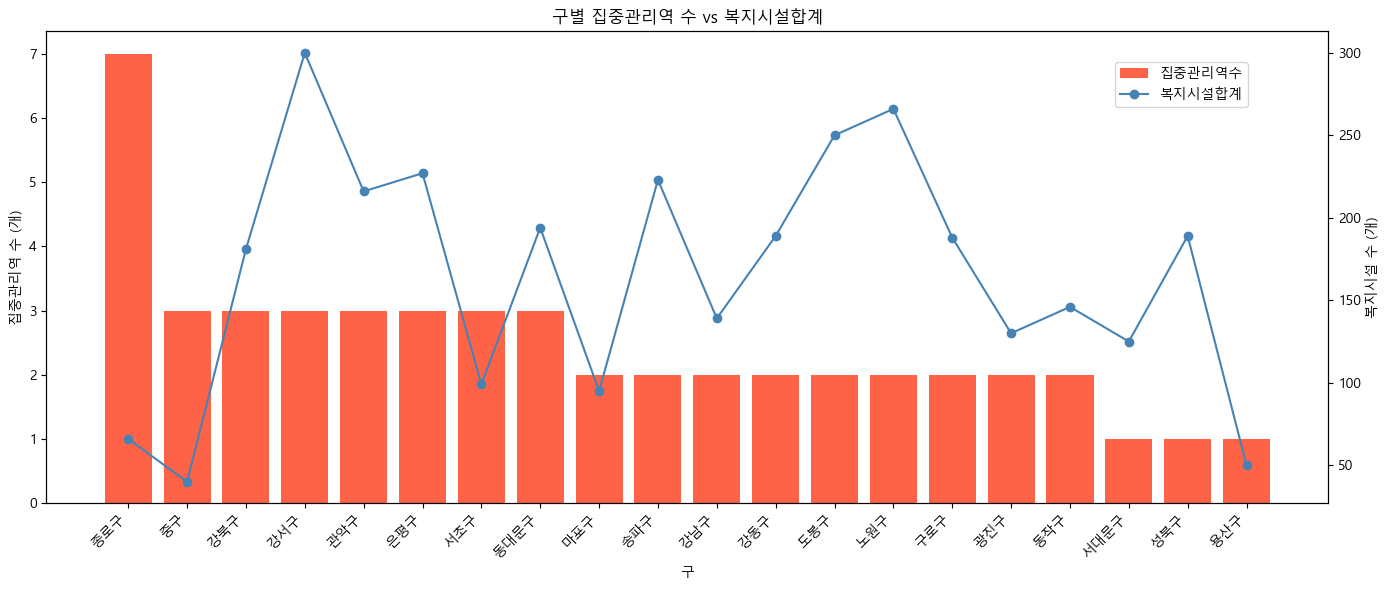

In [23]:
# 시각화 - 구별 집중관리역 수 + 복지시설합계
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(14, 6))

# 막대: 집중관리역 수
bars = ax1.bar(gu_analysis['구'], gu_analysis['집중관리역수'], color='tomato', label='집중관리역수')
ax1.set_ylabel('집중관리역 수 (개)')
ax1.set_xlabel('구')
plt.xticks(rotation=45, ha='right')

# 꺾은선: 복지시설합계
ax2 = ax1.twinx()
ax2.plot(gu_analysis['구'], gu_analysis['복지시설합계'], color='steelblue', marker='o', label='복지시설합계')
ax2.set_ylabel('복지시설 수 (개)')

plt.title('구별 집중관리역 수 vs 복지시설합계')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

In [24]:
print(gu_analysis.columns.tolist())
print(priority_final.columns.tolist())

['구', '집중관리역수', 'EV합계', 'ES합계', 'TOTAL합계', '평균시설부하지수', '요양기관수', '장애인복지관수', '병원수', '복지시설합계']
['역사_ID', '역사명', '호선', '위도', '경도', '역명_key', '호선_우선순위', '구', '요양기관수', '장애인복지관수', '병원수', '무임승하차비중', '무임승하차', '시설부하지수', 'TOTAL', '복지시설합계']


In [25]:
# 서울 25개 구 전체
seoul_25 = ['종로구','중구','용산구','성동구','광진구','동대문구','중랑구','성북구',
            '강북구','도봉구','노원구','은평구','서대문구','마포구','양천구','강서구',
            '구로구','금천구','영등포구','동작구','관악구','서초구','강남구','송파구','강동구']

# 없는 구 찾기
missing = set(seoul_25) - set(gu_analysis['구'].tolist())
print("없는 구:", missing)

없는 구: {'중랑구', '영등포구', '성동구', '양천구', '금천구'}


In [26]:
import pandas as pd

# 구 기준으로 merge
merged_df = priority_final.merge(
    gu_analysis[['구', '집중관리역수', 'EV합계', 'ES합계', 'TOTAL합계', '평균시설부하지수']],
    on='구',
    how='left'
)

# xlsx 저장
merged_df.to_excel('final.xlsx', index=False)
print(f"저장 완료: {len(merged_df)}개 역")

저장 완료: 49개 역
